In [1]:
import kagglehub
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import random_split
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
from skopt.space import Real, Integer, Categorical
from skopt import gp_minimize



In [2]:
# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: /home/omarhammad/.cache/kagglehub/datasets/subhaditya/fer2013plus/versions/1


In [3]:

data_transforms = {
    "train": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomCrop(48, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    "test": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train"
test_dir = path + "/fer2013plus/fer2013/test"

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])


In [4]:
def create_dataloaders(train_dataset, test_dataset, batch_size, val_split=0.2):
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Extract labels for training subset
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]
    class_counts = np.bincount(train_labels)
    class_weights = 1. / np.sqrt(class_counts + 1e-6)
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    # Create WeightedRandomSampler
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_subset, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, val_loader, test_loader

In [5]:
class CNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, 8)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [6]:

def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=100, print_every=100, patience=5):
    """
    Trains a given model with early stopping and logs metrics to TensorBoard.

    Args:
        model: The model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        optimizer: Optimizer for training (e.g., Adam, SGD).
        criterion: Loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        print_every: Frequency (in batches) to print training loss.
        patience: Number of epochs to wait for validation loss improvement before stopping.
    """
    # Initialize TensorBoard writer
    writer = SummaryWriter(log_dir="./logs")

    # Set device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(train_loader):
            # Move data to GPU (if available)
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()

            # Log batch loss to TensorBoard
            if (i + 1) % print_every == 0:
                avg_loss = running_loss / print_every
                writer.add_scalar("Training Loss", avg_loss, epoch * len(train_loader) + i)
                running_loss = 0.0

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        # Log validation loss to TensorBoard
        writer.add_scalar("Validation Loss", val_loss, epoch)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    # Close TensorBoard writer
    writer.close()


In [7]:
def evaluate_model(model, data_loader):
    """
    Evaluates the model's performance on a given dataset.

    Args:
        model: The trained model to evaluate.
        data_loader: DataLoader for the dataset to evaluate.

    Returns:
        float: Accuracy of the model on the dataset.
    """
    # Set the device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to the device
    model = model.to(device)

    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            # Move data to the same device as model
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [8]:
def visualize_predictions(model, data_loader, classes, num_images=8, device='cpu'):
    """
    Visualizes original images with ground truth and predicted labels.

    Args:
        model: The trained model to use for predictions.
        data_loader: DataLoader for the dataset to evaluate.
        classes: List of class names corresponding to the labels.
        num_images: Number of images to visualize (default is 8).
        device: Device to use for model and data ('cpu' or 'cuda').
    """
    model.eval()
    model.to(device)

    # Get a random batch of data
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    num_images = min(num_images, len(images))
    rows = (num_images + 1) // 2
    cols = 2

    plt.figure(figsize=(15, rows * 5))
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy array for display
        img = images[i].cpu().permute(1, 2, 0).numpy()
        # De-normalize if needed
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        true_label = classes[labels[i].item()]
        pred_label = classes[predicted[i].item()]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [9]:
search_space = [
    Real(1e-6, 1e-2, name='learning_rate', prior='log-uniform'),
    Integer(16, 64, name='batch_size'),
    Categorical(['Adam', 'SGD', 'RMSprop', 'AdamW'], name='optimizer'),
    Real(0.1, 0.5, name='dropout_rate'),
    Real(1e-5, 1e-2, name='weight_decay', prior='log-uniform'),
    Integer(3, 10, name='patience')  # Early stopping patience
]


In [10]:
def objective(params):
    learning_rate, batch_size, optimizer_type, dropout_rate, weight_decay, patience = params
    batch_size = int(batch_size)
    patience = int(patience)

    # Set the device (use GPU if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Update data loaders
    train_loader, val_loader, _ = create_dataloaders(train_dataset, test_dataset, batch_size)

    # Define model, criterion, and optimizer
    model = CNN(dropout_rate=dropout_rate).to(device)  # Pass dropout_rate to CNN
    criterion = nn.CrossEntropyLoss()

    # Use the correct optimizer with weight decay
    optimizer = getattr(optim, optimizer_type)(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Early stopping logic
    best_val_loss = float('inf')
    patience_counter = 0

    print(
        f"Starting training with params: lr={learning_rate}, batch_size={batch_size}, optimizer={optimizer_type}, dropout_rate={dropout_rate}, weight_decay={weight_decay}, patience={patience}, device={device}")

    for epoch in range(25):  # Use a high fixed max epoch value
        model.train()
        running_loss = 0.0

        # Training loop
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # Print batch progress
            if (batch_idx + 1) % 100 == 0:  # Every 100 batches
                print(f"Epoch [{epoch + 1}/25], Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")

        # Validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch [{epoch + 1}/25], Validation Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}")
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter if improvement
        else:
            patience_counter += 1
            print(f"No improvement in validation loss. Patience counter: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs")
                break

    # Calculate validation accuracy
    total, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f"Final Validation Accuracy: {val_accuracy:.4f}")
    return -val_accuracy


In [11]:
result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=10,  # Reduced iterations
    random_state=42
)

print("Best parameters:", result.x)
print("Best validation accuracy:", -result.fun)


Starting training with params: lr=0.001535224694197351, batch_size=25, optimizer=AdamW, dropout_rate=0.33874006317859484, weight_decay=0.00021751953118777657, patience=4, device=cuda
Epoch [1/25], Batch [100/909], Loss: 2.0956
Epoch [1/25], Batch [200/909], Loss: 1.9422
Epoch [1/25], Batch [300/909], Loss: 1.6753
Epoch [1/25], Batch [400/909], Loss: 1.6174
Epoch [1/25], Batch [500/909], Loss: 1.8781
Epoch [1/25], Batch [600/909], Loss: 1.4976
Epoch [1/25], Batch [700/909], Loss: 1.7599
Epoch [1/25], Batch [800/909], Loss: 1.8079
Epoch [1/25], Batch [900/909], Loss: 1.7032
Epoch [1/25], Validation Loss: 1.4932
Validation loss improved from inf to 1.4932
Epoch [2/25], Batch [100/909], Loss: 1.7143
Epoch [2/25], Batch [200/909], Loss: 1.8620
Epoch [2/25], Batch [300/909], Loss: 1.4716
Epoch [2/25], Batch [400/909], Loss: 1.3468
Epoch [2/25], Batch [500/909], Loss: 1.4596
Epoch [2/25], Batch [600/909], Loss: 1.5520
Epoch [2/25], Batch [700/909], Loss: 1.9246
Epoch [2/25], Batch [800/909], 

In [12]:
# Extract best parameters from tuning results
# Best parameters: [0.0005262961031076745, Batch_size=38, 'Adam',dropout_rate=0.4768807022739412, weight_decay=0.0004896262051737684, best_patience=6]
best_learning_rate = result.x[0]
best_batch_size = int(result.x[1])
best_optimizer_type = result.x[2]
best_dropout_rate = result.x[3]
best_weight_decay = result.x[4]
best_patience = int(result.x[5])

# Update data loaders with the best batch size
train_loader, val_loader, test_loader = create_dataloaders(train_dataset, test_dataset, best_batch_size)

# Define the model, criterion, and optimizer
best_cnn_model = CNN(dropout_rate=best_dropout_rate)  # Pass the best dropout rate
criterion = nn.CrossEntropyLoss()

# Use the best optimizer type with weight decay
optimizer = getattr(torch.optim, best_optimizer_type)(
    best_cnn_model.parameters(),
    lr=best_learning_rate,
    weight_decay=best_weight_decay
)

# Train the model with early stopping
train_model(
    model=best_cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=50,  # High fixed value, let early stopping decide
    print_every=100,
    patience=best_patience
)

Epoch [1/50], Validation Loss: 1.5573
Epoch [2/50], Validation Loss: 1.2258
Epoch [3/50], Validation Loss: 1.0987
Epoch [4/50], Validation Loss: 1.0311
Epoch [5/50], Validation Loss: 0.9871
Epoch [6/50], Validation Loss: 0.9561
Epoch [7/50], Validation Loss: 0.9209
Epoch [8/50], Validation Loss: 0.9110
Epoch [9/50], Validation Loss: 0.8843
Epoch [10/50], Validation Loss: 0.8850
Epoch [11/50], Validation Loss: 0.8695
Epoch [12/50], Validation Loss: 0.8539
Epoch [13/50], Validation Loss: 0.9316
Epoch [14/50], Validation Loss: 0.8676
Epoch [15/50], Validation Loss: 0.8346
Epoch [16/50], Validation Loss: 0.8417
Epoch [17/50], Validation Loss: 0.8145
Epoch [18/50], Validation Loss: 0.7966
Epoch [19/50], Validation Loss: 0.8038
Epoch [20/50], Validation Loss: 0.8157
Epoch [21/50], Validation Loss: 0.8203
Epoch [22/50], Validation Loss: 0.7921
Epoch [23/50], Validation Loss: 0.7949
Epoch [24/50], Validation Loss: 0.7923
Epoch [25/50], Validation Loss: 0.7670
Epoch [26/50], Validation Loss: 0.

In [19]:
# Save the model's state_dict
torch.save(best_cnn_model.state_dict(), 'best_cnn_model.pth')

In [21]:
# Initialize the model with the same architecture
loaded_cnn_model = CNN(dropout_rate=best_dropout_rate)  # Ensure architecture matches

# Map to the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the state_dict with map_location
state_dict = torch.load("best_cnn_model.pth", map_location=device)
loaded_cnn_model.load_state_dict(state_dict)

# Move the model to the correct device and set to eval mode
loaded_cnn_model.to(device)
loaded_cnn_model.eval()


/tmp/ipykernel_6863/108647630.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("best_cnn_model.pth", map_location=device)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.4768807022739412, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=8, bias=True)
)

In [22]:
test_accuracy = evaluate_model(loaded_cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 73.12%


In [23]:
train_accuracy = evaluate_model(loaded_cnn_model, train_loader)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")

Train Accuracy: 75.52%


In [24]:
# Prepare to count predictions for each class
classes = train_dataset.classes  # Get class names from the dataset
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# Set the device (CUDA if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move the model to the selected device
cnn_model = loaded_cnn_model.to(device)

# Ensure the model is in evaluation mode
cnn_model.eval()

# Disable gradients for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data

        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)

        # Get predictions from the model
        outputs = cnn_model(images)
        _, predictions = torch.max(outputs, 1)

        # Collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            label_name = classes[label.item()]
            if label == prediction:
                correct_pred[label_name] += 1
            total_pred[label_name] += 1

# Print accuracy for each class
for classname, correct_count in correct_pred.items():
    if total_pred[classname] > 0:
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:10s} is {accuracy:.1f} %')
    else:
        print(f'No predictions for class: {classname}')


Accuracy for class: anger      is 77.8 %
Accuracy for class: contempt   is 41.2 %
Accuracy for class: disgust    is 40.4 %
Accuracy for class: fear       is 48.5 %
Accuracy for class: happiness  is 86.2 %
Accuracy for class: neutral    is 65.8 %
Accuracy for class: sadness    is 61.8 %
Accuracy for class: surprise   is 83.6 %


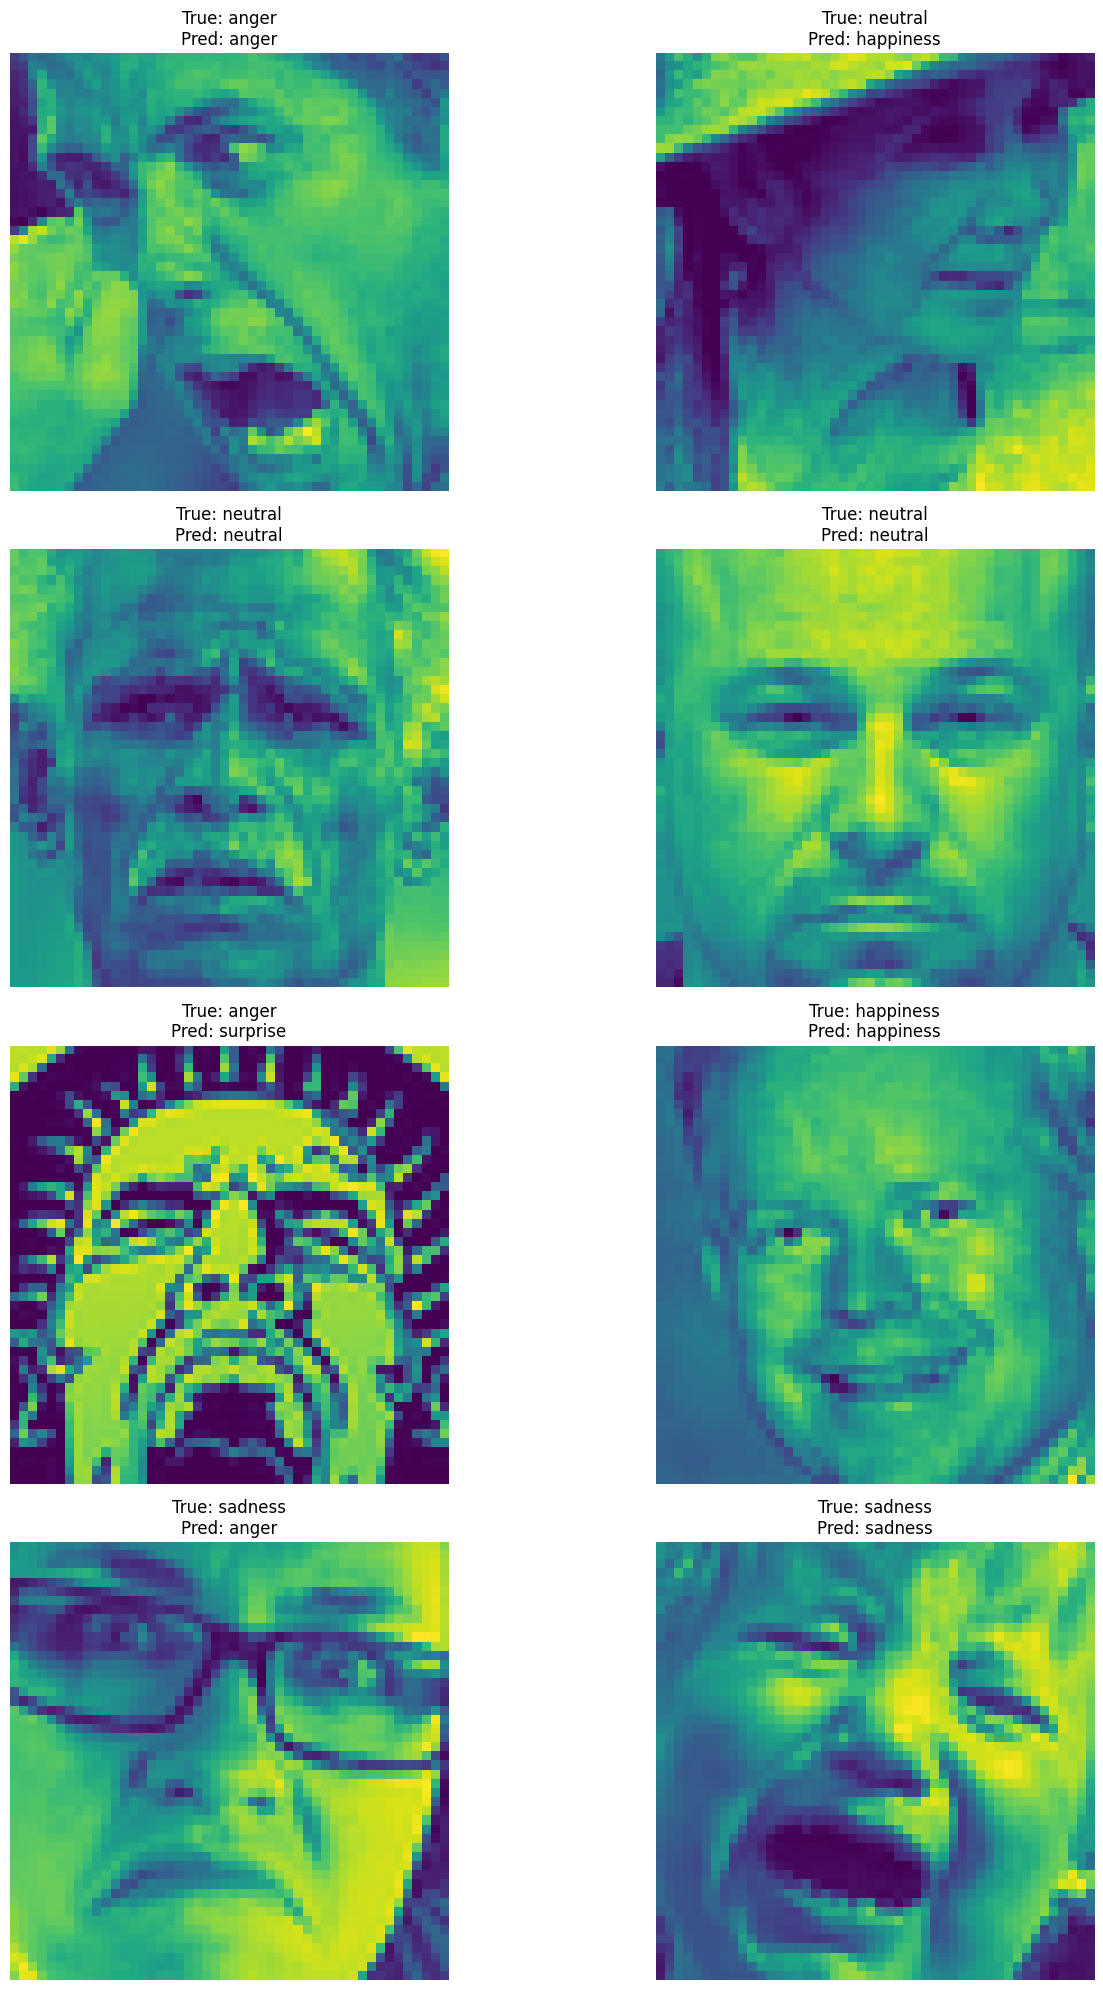

In [25]:
# Define class names
classes = train_dataset.classes  # Assuming you use ImageFolder or a similar dataset

# Visualize predictions
visualize_predictions(
    model=loaded_cnn_model,  # Your trained model
    data_loader=test_loader,  # DataLoader for the test dataset
    classes=classes,  # Class names
    num_images=8,  # Number of images to visualize
    device='cuda'  # Use 'cuda' if running on GPU
)